## Final Project : Solving ODEs
### By : Rory Huck

### Important Note:
#### I referenced this site a lot to help me build a lot of my logic for the classification and the overall structure of the ODE solver below. 
#### “Ordinary Differential Equations.” SymPy Documentation, https://docs.sympy.org/latest/modules/solvers/ode.html. Accessed 10 Apr. 2026.

### Instructions for code below:
#### To use this ODE classifier and solver, users will be prompted to enter the right-hand side of the differential equation they wish to solve in the form dy/dx = F(x, y(x)). Python style syntax is required for the program to interpret the equation correctly. This tool treats y as a function, so it must always be written as y(x) when used in the expression. After entering the equation, users will be asked whether they would like to include initial conditions. If selected, they will enter an x-value and corresponding y-value, which will allow the program to compute a particular solution instead of the general solution. The program will then solve and classify the differential equation and display the final solution, along with a graph and slope field to help visualize the behavior of the system. 

#### For example, to input the equation dy/dx = xy, users would type xy(x) using * for multiplication, ** for powers, and exp(x) for exponentials. For initial conditions such as x0 = 0 and y(x0) = 1, users would simply enter 0 and 1 when prompted.

In [1]:
# Imports
import sympy as sp
sp.init_printing()
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import messagebox

#### List of ODE Examples to Try:

**Separable ODEs:**
- x*y(x)
- y(x)/x
- sin(x)*y(x)
- x**2 * y(x)**2

**Separable with Initial Conditions:**
- x*y(x), x0=0, y0=1
- y(x)/x, x0=1, y0=2
- sin(x)*y(x), x0=0, y0=1
- x**2 * y(x)**2, x0=0, y0=1

**Linear ODEs:**
- x + y(x)
- 2*y(x) + x
- y(x) - x
- exp(x)*y(x)

**Linear with Initial Conditions:**
- x + y(x), x0=0, y0=1
- y(x) - x, x0=0, y0=2
- 2*y(x) + x, x0=0, y0=1
- exp(x)*y(x), x0=0, y0=1

**Slope Field Examples:**
- x + y(x)
- y(x) - x
- sin(x) - y(x)
- x - y(x)

**Tricky Test Cases:**
- (y(x) + 1)/x
- (x + y(x))/x
- y(x)**2 + x
- exp(x + y(x))

**Edge Cases:**
- 1/x
- y(x)/x, x0=0
- log(x)*y(x)

**Best Demo Examples:**
- sin(x)*y(x), x0=0, y0=1
- x - y(x), x0=0, y0=1
- (y(x)+1)/x, x0=1, y0=1

In [2]:
# Define variables
x = sp.symbols('x')
y = sp.Function('y')

def classify_ode(rhs):
    try:
        if sp.separatevars(rhs, symbols=[x, y(x)]):
            return "Separable"
    except:
        pass
    
    if rhs.has(y(x)):
        return "First-order linear"
    
    return "Unknown"


def solve_with_steps(rhs, ics=None):
    eq = sp.Eq(sp.diff(y(x), x), rhs)
    
    print("\nDifferential Equation:")
    display(eq)
    
    ode_type = classify_ode(rhs)
    print("\nType:", ode_type)
    
    # Step-by-step (separable only)
    if ode_type == "Separable":
        print("\nStep by Step Solution:")
        
        Y = sp.symbols('Y')
        rhs_temp = rhs.subs(y(x), Y)
        
        separated = sp.separatevars(rhs_temp, symbols=[x, Y], dict=True)
        
        if separated:
            f_x = separated[x]
            g_y = separated[Y]
            
            print("1) Separate variables:")
            display(sp.Eq(1/g_y * sp.diff(y(x), x), f_x))
            
            print("2) Integrate both sides:")
            left = sp.integrate(1/g_y, y(x))
            right = sp.integrate(f_x, x)
            display(sp.Eq(left, right))
        else:
            print("Could not separate variables.")
    
    # Solve
    if ics:
        solution = sp.dsolve(eq, ics=ics)
    else:
        solution = sp.dsolve(eq)
    
    print("\nFinal Solution:")
    display(solution)
    
    return solution, eq


def plot_solution(solution):
    try:
        sol_expr = solution.rhs
        f = sp.lambdify(x, sol_expr, 'numpy')

        x_vals = np.linspace(-5, 5, 200)
        y_vals = f(x_vals)

        plt.figure()
        plt.plot(x_vals, y_vals)
        plt.title("Solution Curve")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.grid()
        plt.show()
    except:
        print("Could not plot solution.")


def slope_field(rhs):
    try:
        f = sp.lambdify((x, y(x)), rhs, 'numpy')

        X, Y = np.meshgrid(np.linspace(-5,5,20), np.linspace(-5,5,20))
        U = np.ones_like(X)
        V = f(X, Y)

        plt.figure()
        plt.quiver(X, Y, U, V)
        plt.title("Slope Field")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.show()
    except:
        print("Could not generate slope field.")

In [3]:
# user input
user_input = input("Enter dy/dx = ")
rhs = sp.sympify(user_input)

# initial condition
use_ic = input("Do you want to enter an initial condition? (y/n): ")

ics = None
if use_ic.lower() == 'y':
    x0 = float(input("Enter x0: "))
    y0 = float(input("Enter y(x0): "))
    ics = {y(x0): y0}

# solve first!
solution, eq = solve_with_steps(rhs, ics)

Enter dy/dx =  2*y(x)+x
Do you want to enter an initial condition? (y/n):  n



Differential Equation:



Type: Separable

Step by Step Solution:
Could not separate variables.

Final Solution:


Could not plot solution.


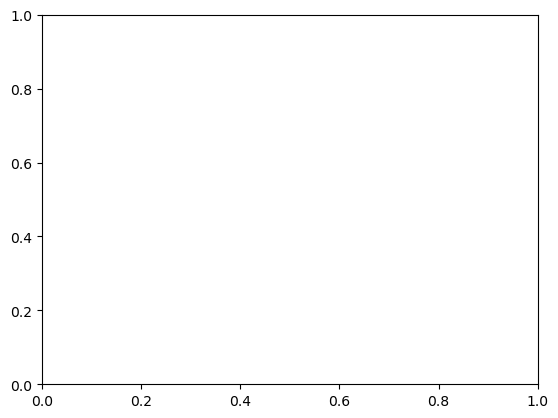

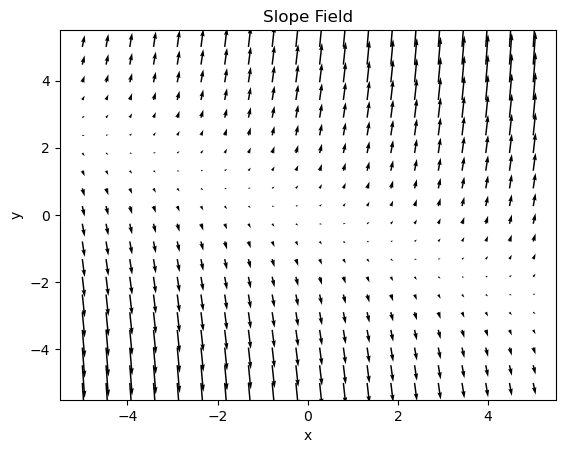

In [4]:
# plots after solution
plot_solution(solution)
slope_field(rhs)